# **Chapter2: Neural Networks with PyTorch**

This chapter introduces the main ideas behind neural networks and then applies them in PyTorch on the Iris dataset. The goal is to connect the core concepts to a practical classification example.


## **Setup and data preparation**

To keep the workflow consistent with chapter 1, this chapter also uses the Iris dataset. We encode the labels, scale the features, and prepare PyTorch tensors and data loaders before defining the models.


In [1]:
# Required modules

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# Load the Iris dataset into a DataFrame
iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.copy()
iris = iris.rename(columns={'target': 'species'})
iris['species'] = iris['species'].map(dict(enumerate(iris_bunch.target_names)))

# Prepare features and labels
df = iris.copy()
X = df.drop(['species'], axis=1)
y = df['species']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


Using device: cpu
(120, 4)
(30, 4)
(120,)
(30,)


## **What is a Neural Network?**


One kind of **computational model** that draws inspiration from the architecture and operations of the **human brain** is the neural network. Using **input data** as training data, the network is trained to **recognize patterns** and make predictions or decisions. This mathematical framework helps solve complicated problems.

## **What are the fundamental building blocks of a neural network?**


**Perceptron(Neuron/Node)**

The fundamental unit of a neural network is the **neuron**, also known as the **node**. After applying a *mathematical transformation*, it takes in input data and outputs an output. In a neural network, neurons are arranged in layers and are in charge of processing and changing data.


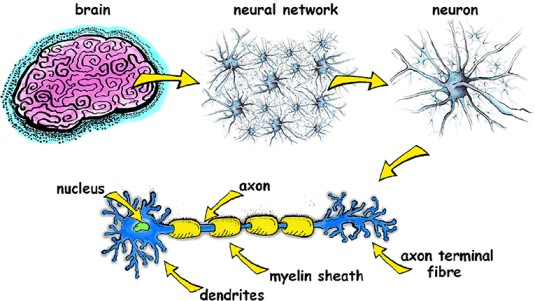

The **perceptron** is a type of **artificial neural network** that was developed in the 1950s by *Frank Rosenblatt*. It is one of the simplest forms of a neural network and serves as the foundation for many other more complex neural network architectures. The perceptron is a **single-layer neural network** that can be used for binary classification tasks, where the goal is to classify input data into one of two classes.

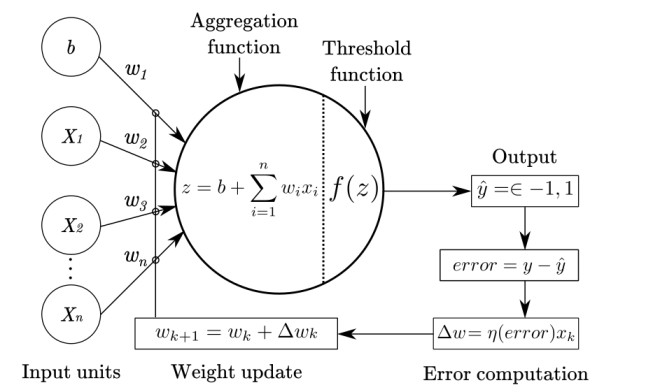

**Layers**

- A neural network's **layer** is a collection of **neurons** arranged in a certain way. There are **input, hidden, and output layers** among the various kinds of layers.                                                   
- Input layers receive data as input, hidden layers perform intermediate computations, and output layers produce the final predictions or outputs of the neural network.

### **What are the various neural network layers?**

**Input Layer:**
> The input layer is the first layer in a neural network that receives the raw input data. It acts as a buffer between the raw data and the rest of the neural network. Each node in the input layer corresponds to a feature or attribute in the input data, and the values of these nodes represent the input data. The input layer simply passes the input data to the next layer without applying any computation.

**Hidden Layers:**
> Hidden layers are the intermediate layers between the input and output layers in a neural network. They perform computations on the input data to extract relevant features and learn representations that are useful for making predictions. Hidden layers apply mathematical transformations to the input data using weights, biases, and activation functions to produce an output that is passed to the next layer. The number of hidden layers and the number of neurons in each hidden layer are hyperparameters that need to be determined based on the problem at hand and the complexity of the data.

**Output Layer:**
> The output layer is the last layer in a neural network that produces the final prediction or output. The number of nodes in the output layer depends on the type of problem being solved. For example, in binary classification tasks, the output layer typically has one node that produces a binary prediction (e.g., 0 or 1). In multi-class classification tasks, the output layer may have multiple nodes corresponding to different classes, and the prediction is obtained by selecting the class with the highest output value. In regression tasks, the output layer may produce a continuous value as the prediction.

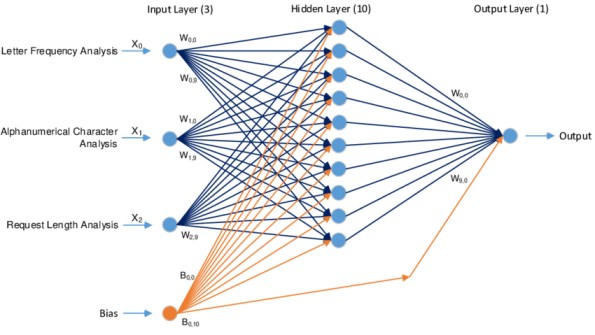

## **What are a neural network's two key propagations?**

After passing through a neural network and a number of statistical transformations, the data produces an output for us. In a neural network, there are two primary data motions: feed forward and back propagation. Let's investigate them.

**Feed Forward**

In order to generate a prediction or output, feedforward involves moving input data from the input layer to the output layer of the neural network in a forward direction. In feedforward, each neuron in each layer receives an activation function, multiplied by the weights, and biases added in order to produce the output of that particular neuron. The process continues until the output layer yields the final prediction, at which point this output serves as the input for the subsequent layer.

**The following is a summary of a neural network's feedforward steps:**


>1. Take the input data and send it to the first hidden layer via the input layer.

> 2. Add biases and multiply the input data by the weights.

>3. To get the neuron's output, apply an activation function to the weighted sum of the inputs and biases.

> 4. Send the neuron's output as input to the following layer.

> 5. Continue doing steps 2-4 for every neuron in every hidden layer until you reach the output layer.

> 6. Retrieve the output layer's final prediction.


**Back Propagation**

In order to reduce the error between the predicted and actual outputs, backpropagation involves adjusting the weights and biases in a neural network during the training phase. It entails calculating the gradient of the loss function with respect to the biases and weights, and then updating the neural network's parameters using this gradient. When training data has access to ground truth labels, backpropagation is employed in supervised learning.

**A neural network's back propagation steps can be summed up as follows:**

>1. Determine the loss or error that exists between the expected and actual outputs.   

>2. Determine the loss function's gradient in relation to the output layer's outputs. Methods like cross-entropy loss and mean squared error (MSE) can be used for this. 

>3. To calculate the gradient of the loss function with respect to the inputs of the neurons in the output layer, use the calculus chain rule.

> 4. Using the computed gradient and an optimization technique like gradient descent to minimize the loss function, update the output layer's weights and biases.

> 5. Determine the gradient of the loss function in relation to the neurons' inputs in the hidden layer that came before it.

> 6. Using the computed gradient and the optimization algorithm, update the weights and biases of the previous hidden layer.

> 7. Go backwards from the output layer to the input layer and repeat steps 5–6 for every hidden layer.

> 8. Continue doing this all over for a predetermined number of epochs, or until convergence is achieved.



Let’s explore them.

In the feedforward propagation, the Activation Function is a mathematical “gate” in between the input feeding the current neuron and its output going to the next layer.

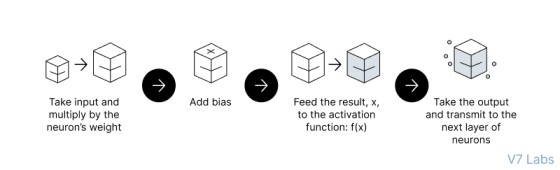

To put it simply—backpropagation aims to minimize the cost function by adjusting the network’s weights and biases. The cost function gradients determine the level of adjustment with respect to parameters like activation function, weights, bias, etc.

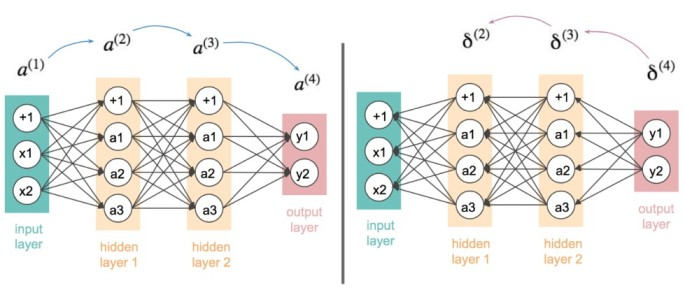

**We often employ two techniques to carry out feed forwarding and back propagating**


> **Optimization Functions** *(For Back Propagation)*

> **Activation Functions** *(For Feed Forward)*



## **Activation Functions**

A mathematical function that is applied to a neuron's output is called an activation function. It gives the neural network non-linearity, which enables it to recognize intricate patterns in data. ReLU (Rectified Linear Unit), sigmoid, and tanh are examples of common activation functions.

Well, the purpose of an activation function is to add non-linearity to the neural network.

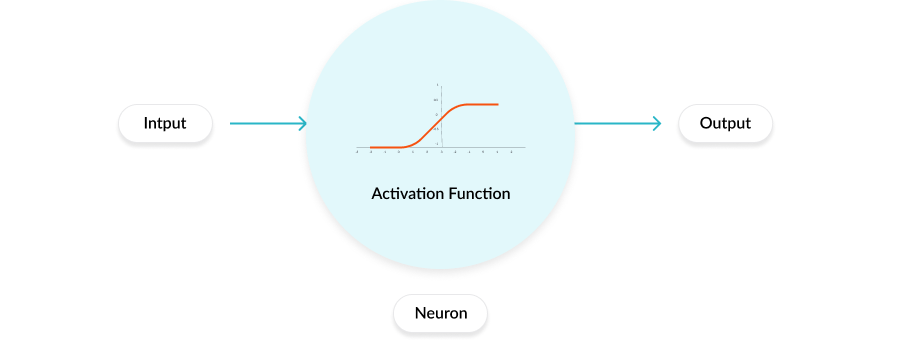

Activation functions introduce an additional step at each layer during the **forward propagation**, but its computation is worth it. Here is why—

Let’s suppose we have a neural network working without the activation functions.

In that case, every neuron will only be performing a linear transformation on the inputs using the weights and biases. It’s because it doesn’t matter how many hidden layers we attach in the neural network; all layers will behave in the same way because the composition of two linear functions is a linear function itself.

Although the neural network becomes simpler, learning any complex task is impossible, and our model would be just a linear regression model.

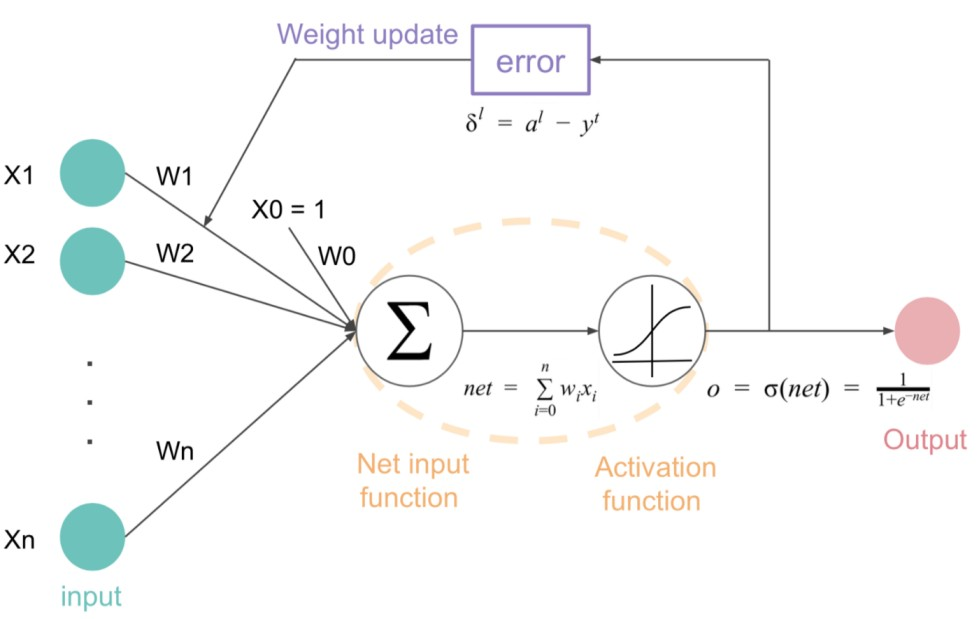

**A neural network with 1 activation unit. The activation unit summarizes all inputs including bias unit (x0). Then compute output using activation function. After that, the network will compute cost function and sent the error back to adjust weights until we get minimize cost.**

### **Types of Neural Networks Activation Functions**

Now that the fundamental ideas have been discussed, let's review the most widely used activation functions for neural networks.

#### **Binary Step Function**

Binary step function depends on a threshold value that decides whether a neuron should be activated or not.

The input fed to the activation function is compared to a certain threshold; if the input is greater than it, then the neuron is activated, else it is deactivated, meaning that its output is not passed on to the next hidden layer.

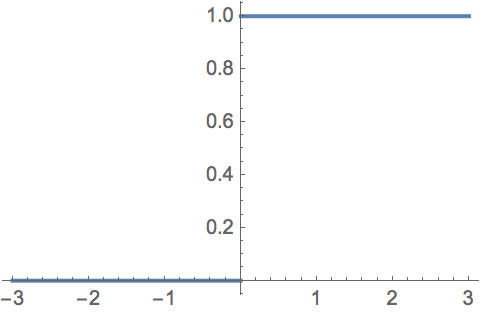

Mathematically it can be represented as:



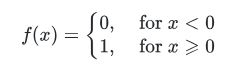

Here are some of the limitations of binary step function:

It cannot provide multi-value outputs—for example, it cannot be used for multi-class classification problems.
The gradient of the step function is zero, which causes a hindrance in the backpropagation process.

#### **Linear Activation Function**

When the activation is proportionate to the input, the linear activation function is also referred to as the identity function.

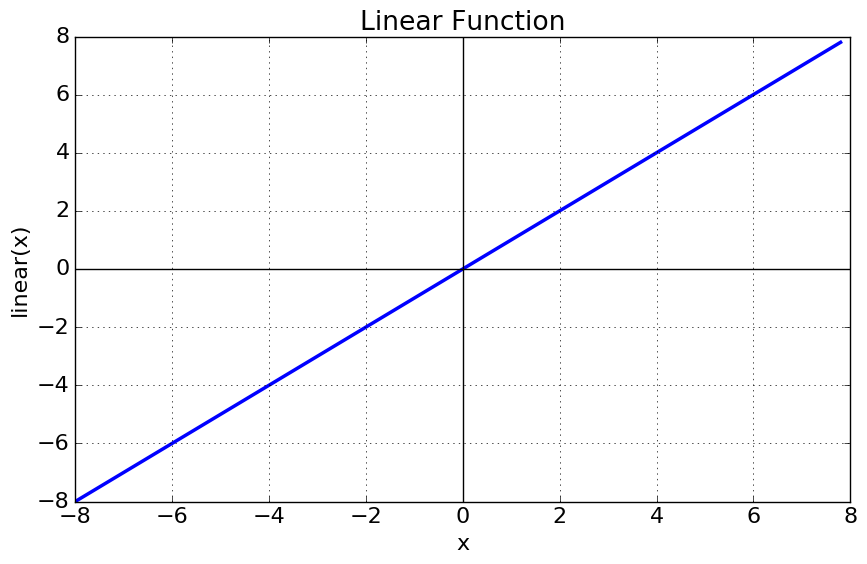

Mathematically it can be represented as:

f(x) = x

**However, there are two main issues with a linear activation function:**

> 1. Since the function's derivative is a constant and unrelated to the input x, backpropagation is not an option.

> 2. A linear activation function will cause the neural network's layers to merge into one. The final layer of a neural network is always a linear function of the first layer, regardless of how many layers it has. Thus, the neural network becomes just one layer when the activation function is linear.



#### **Non-Linear Activation Function**

The linear activation function shown above is simply a `linear regression model`.

Because of its limited power, this does not allow the model to create complex mappings between the network’s inputs and outputs.

__Non-linear activation functions solve the following limitations of linear activation functions:__

>**They allow backpropagation because now the derivative function would be related to the input, and it’s possible to go back and understand which weights in the input neurons can provide a better prediction.**

>**They allow the stacking of multiple layers of neurons as the output would now be a non-linear combination of input passed through multiple layers. Any output can be represented as a functional computation in a neural network.**

**Now, let’s have a look at ten different non-linear neural networks activation functions and their characteristics.**

#### **Ten Non-Linear Neural Networks Activation Functions :**

**1. Sigmoid / Logistic Activation Function**

This function takes any real value as input and outputs values in the range of 0 to 1.

The larger the input (more positive), the closer the output value will be to 1.0, whereas the smaller the input (more negative), the closer the output will be to 0.0, as shown below.

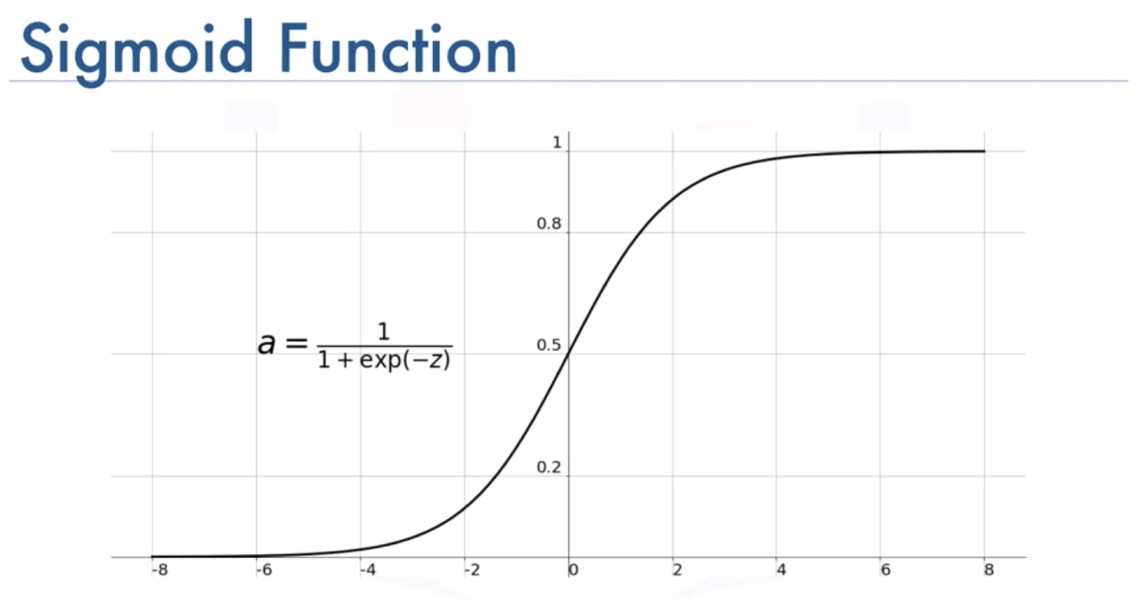

Mathematically it can be represented as:

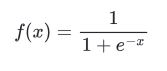

Here’s why sigmoid/logistic activation function is one of the most widely used functions:

>**It is commonly used for models where we have to predict the probability as an output. Since probability of anything exists only between the range of 0 and 1, sigmoid is the right choice because of its range.**

>**The function is differentiable and provides a smooth gradient, i.e., preventing jumps in output values. This is represented by an S-shape of the sigmoid activation function.**

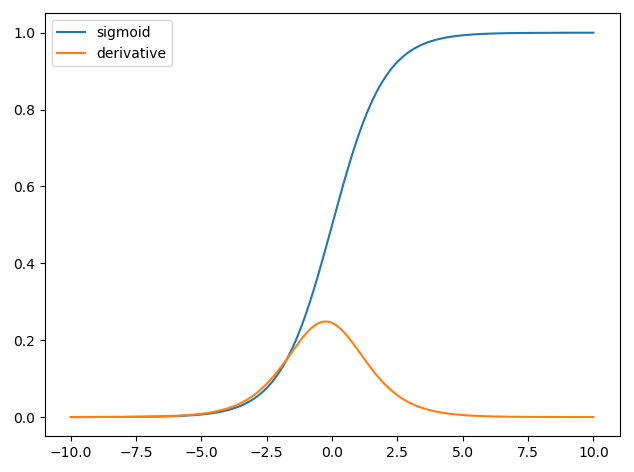

As we can see from the above Figure, the gradient values are only significant for range -3 to 3, and the graph gets much flatter in other regions.

It implies that for values greater than 3 or less than -3, the function will have very small gradients. As the gradient value approaches zero, the network ceases to learn and suffers from the Vanishing gradient problem.

The output of the logistic function is not symmetric around zero. So the output of all the neurons will be of the same sign. This makes the training of the neural network more difficult and unstable.

**2.Tanh Function (Hyperbolic Tangent)**

Tanh function is very similar to the sigmoid/logistic activation function, and even has the same S-shape with the difference in output range of -1 to 1. In Tanh, the larger the input (more positive), the closer the output value will be to 1.0, whereas the smaller the input (more negative), the closer the output will be to -1.0.

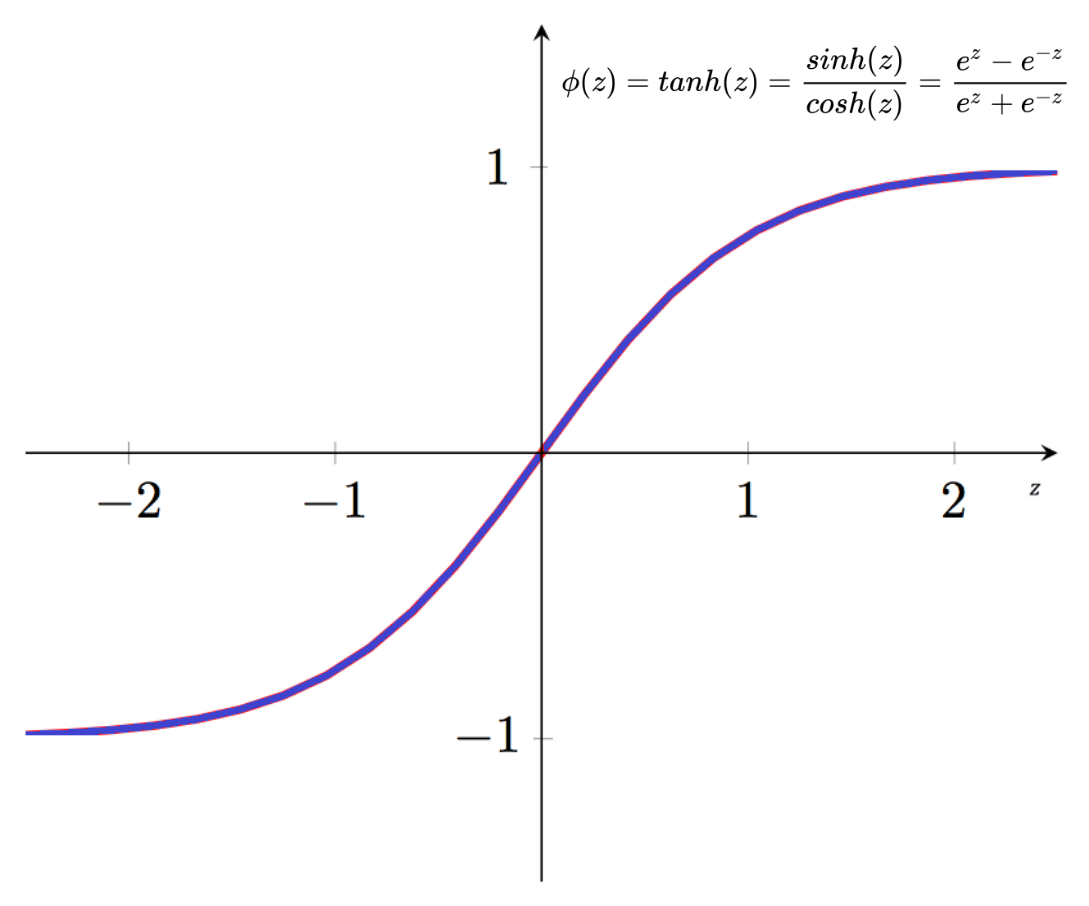

Mathematically it can be represented as:


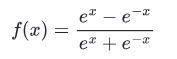

Advantages of using this activation function are:

>**The output of the tanh activation function is Zero centered; hence we can easily map the output values as strongly negative, neutral, or strongly positive.**

>**Usually used in `hidden layers `of a neural network as its values lie between -1 to; therefore, the mean for the hidden layer comes out to be 0 or very close to it. It helps in centering the data and makes learning for the next layer much easier.**

**3. ReLU Function**

ReLU stands for Rectified Linear Unit.

Although it gives an impression of a linear function, ReLU has a derivative function and allows for backpropagation while simultaneously making it computationally efficient.

The main catch here is that the ReLU function does not activate all the neurons at the same time.

The neurons will only be deactivated if the output of the linear transformation is less than 0.

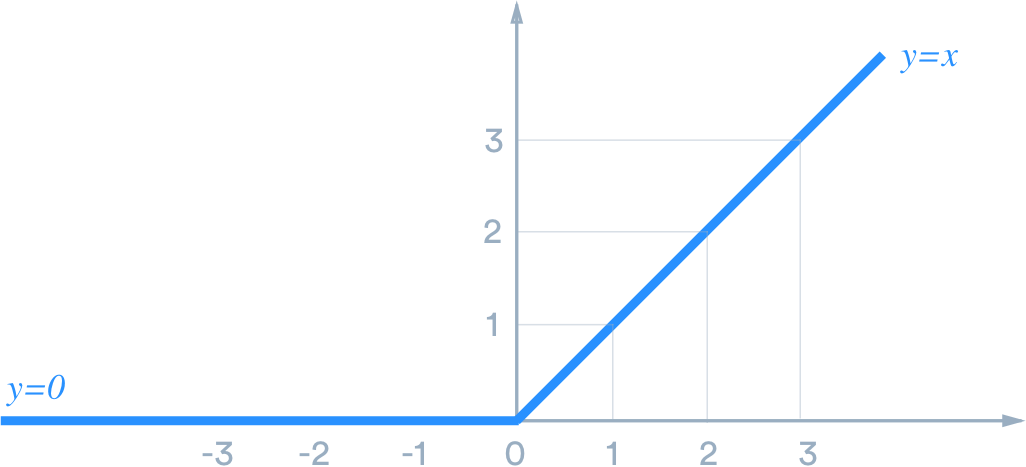

Mathematically it can be represented as:


f(x) = max (0, x)

**The advantages of using ReLU as an activation function are as follows:**

>* Since only a certain number of neurons are activated, the ReLU function is far more computationally efficient when compared to the sigmoid and tanh functions.

>* ReLU accelerates the convergence of gradient descent towards the global minimum of the loss function due to its linear, non-saturating property.

**4.Leaky ReLU Function**

Leaky ReLU is an improved version of ReLU function to solve the Dying ReLU problem as it has a small positive slope in the negative area.

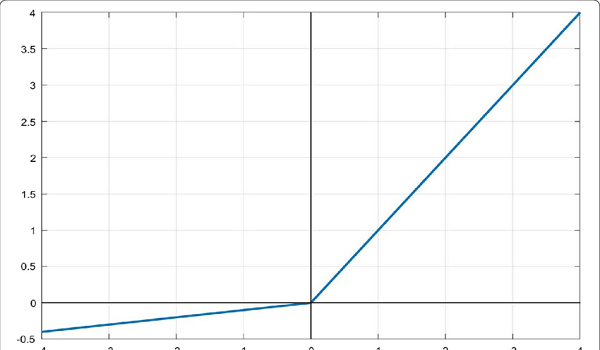

Mathematically it can be represented as:

f(x) = max (0.01x, x)

The advantages of Leaky ReLU are same as that of ReLU, in addition to the fact that it does enable backpropagation, even for negative input values.

**5. Parametric ReLU Function**

Parametric ReLU is another variant of ReLU that aims to solve the problem of gradient’s becoming zero for the left half of the axis.

This function provides the slope of the negative part of the function as an argument a. By performing backpropagation, the most appropriate value of a is learnt.

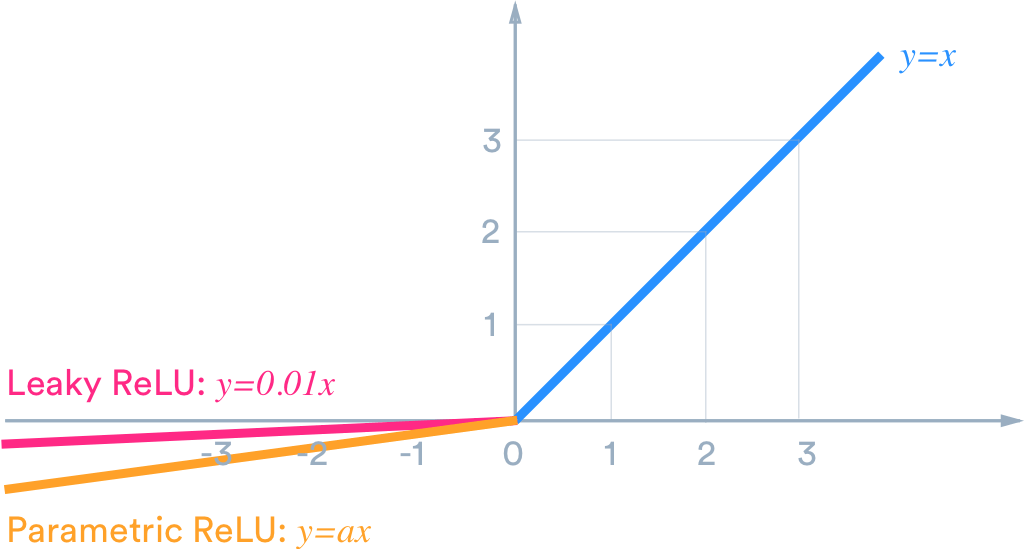

Mathematically it can be represented as:

f(x) = max (ax, x)

Where "a" is the slope parameter for negative values.

The parameterized ReLU function is used when the leaky ReLU function still fails at solving the problem of dead neurons, and the relevant information is not successfully passed to the next layer.

This function’s limitation is that it may perform differently for different problems depending upon the value of slope parameter a.

**6. Exponential Linear Units (ELUs) Function**

Exponential Linear Unit, or ELU for short, is also a variant of ReLU that modifies the slope of the negative part of the function.

ELU uses a log curve to define the negativ values unlike the leaky ReLU and Parametric ReLU functions with a straight line.

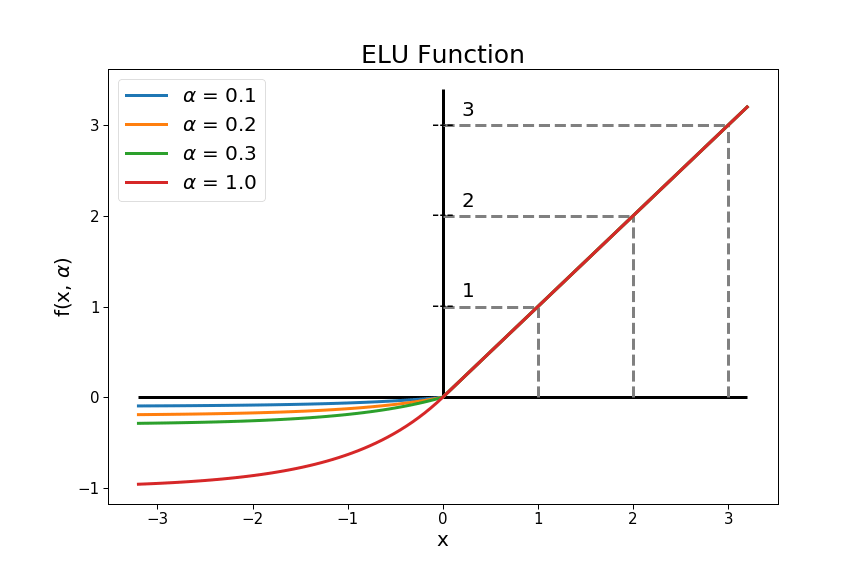

Mathematically it can be represented as:


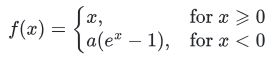

**ELU is a strong alternative for f ReLU because of the following advantages:**

>* ELU becomes smooth slowly until its output equal to -α whereas RELU sharply smoothes.
>* Avoids dead ReLU problem by introducing log curve for negative values of input. It helps the network nudge weights and biases in the right direction.

**7. Softmax Function**

Before exploring the ins and outs of the Softmax activation function, we should focus on its building block—the sigmoid/logistic activation function that works on calculating probability values.



The output of the sigmoid function was in the range of 0 to 1, which can be thought of as probability.

But—This function faces certain problems.

Let’s suppose we have five output values of 0.8, 0.9, 0.7, 0.8, and 0.6, respectively. How can we move forward with it?

The answer is: We can’t.

The above values don’t make sense as the sum of all the classes/output probabilities should be equal to 1.

You see, the Softmax function is described as a `combination of multiple sigmoids.`

It calculates the relative probabilities. `Similar to the sigmoid/logistic activation function, the SoftMax function returns the probability of each class.`

It is most commonly used as an `activation function for the last layer of the neural network in the case of multi-class classification.`

Mathematically it can be represented as:



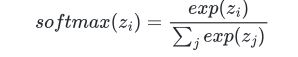

**You can see now how softmax activation function make things easy for `multi-class classification problems`.**


**8. Swish**

It is a self-gated activation function developed by researchers at Google.

Swish consistently matches or outperforms ReLU activation function on deep networks applied to various challenging domains such as `image classification, machine translation etc.`

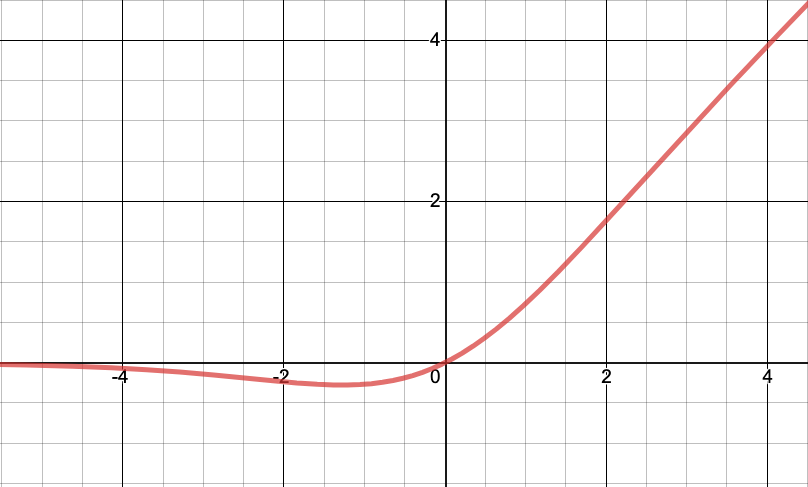

This function is bounded below but unbounded above i.e. Y approaches to a constant value as approaches negative infinity but Y approaches to infinity as X approaches infinity.

Mathematically it can be represented as:

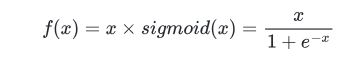



**Here are a few advantages of the Swish activation function over ReLU:**

>* Swish is a smooth function that means that it does not abruptly change direction like ReLU does near x=0. Rather, it smoothly bends from 0 towards values < 0 and then upwards again.

>* Small negative values were zeroed out in ReLU activation function. However, those negative values may still be relevant for capturing patterns underlying the data. Large negative values are zeroed out for reasons of sparsity making it a win-win situation.

>* The swish function being non-monotonous enhances the expression of input data and weight to be learnt.

**9.Gaussian Error Linear Unit (GELU)**

The Gaussian Error Linear Unit (GELU) activation function is compatible with BERT, ROBERTa, ALBERT, and other top NLP models. This activation function is motivated by combining properties from dropout, zoneout, and ReLUs.

ReLU and dropout together yield a neuron’s output. ReLU does it deterministically by multiplying the input by zero or one (depending upon the input value being positive or negative) and dropout stochastically multiplying by zero.

RNN regularizer called zoneout stochastically multiplies inputs by one.

We merge this functionality by multiplying the input by either zero or one which is stochastically determined and is dependent upon the input. We multiply the neuron input X by , where 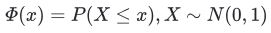 is the cumulative distribution function of the standard normal distribution.

**This distribution is chosen since neuron inputs tend to follow a `normal distribution, especially with Batch Normalization.`**

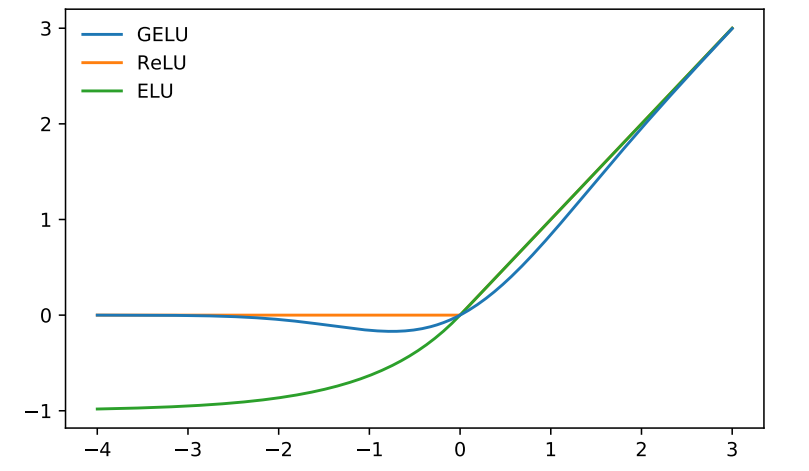

Mathematically it can be represented as:

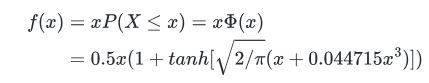

GELU nonlinearity is better than ReLU and ELU activations and finds performance improvements across all tasks in domains of computer vision, natural language processing, and speech recognition.

**10.Scaled Exponential Linear Unit (SELU)**

SELU was defined in self-normalizing networks and takes care of internal normalization which means each layer preserves the mean and variance from the previous layers. SELU enables this normalization by adjusting the mean and variance.

SELU has both positive and negative values to shift the mean, which was impossible for ReLU activation function as it cannot output negative values.

Gradients can be used to adjust the variance. The activation function needs a region with a gradient larger than one to increase it.

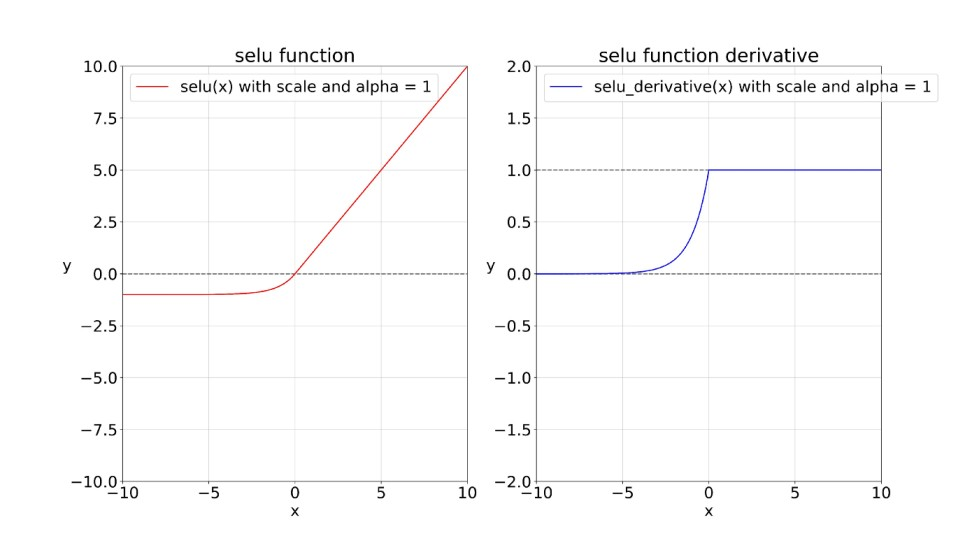

Mathematically it can be represented as:

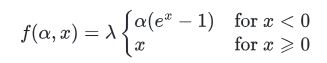


SELU has values of alpha α and lambda λ predefined.

**Here’s the main advantage of SELU over ReLU:**

>* Internal normalization is faster than external normalization, which means the network converges faster.

SELU is a relatively newer activation function and needs more papers on architectures such as CNNs and RNNs, where it is comparatively explored.

### **How to choose the right Activation Function?**

**You need to match your activation function for your output layer based on the type of prediction problem that you are solving—specifically, the type of predicted variable.**

Here’s what you should keep in mind.

**As a rule of thumb, you can begin with using the `ReLU` activation function and then move over to other activation functions if ReLU doesn’t provide optimum results.**

And here are a few other guidelines to help you out:

>* **`ReLU` activation function should only be used in the `hidden layers`.**

>* **`Sigmoid/Logistic and Tanh` functions `should not be used in hidden layers as they make the model more susceptible to problems during training (due to vanishing gradients)`.**

>* **`Swish` function is used in neural networks having a `depth greater than 40 layers`.**


Finally, a few rules for choosing the activation function for your `output layer based on the type of prediction problem` that you are solving:

>* **Regression - Linear Activation Function**

>* **Binary Classification - Sigmoid/Logistic Activation Function**

>* **Multiclass Classification - Softmax**

>* **Multilabel Classification - Sigmoid**





The activation function used in `hidden layers` is typically chosen based on the `type of neural network architecture`:

>* **Convolutional Neural Network (CNN): ReLU activation function.**
>* **Recurrent Neural Network: Tanh and/or Sigmoid activation function.**

### **A Brief Overview of Neural Network Activation Functions**


Let's quickly review everything you learned about active function now:

>* **Activation Functions are used to introduce non-linearity in the network.**
>* **A neural network will almost always have the same activation function in all hidden layers. This activation function should be differentiable so that the parameters of the network are learned in backpropagation.**
>* **ReLU is the most commonly used activation function for hidden layers.**
>* **While selecting an activation function, you must consider the problems it might face: vanishing and exploding gradients.**
>* **Regarding the output layer, we must always consider the expected value range of the predictions. If it can be any numeric value (as in case of the regression problem) you can use the linear activation function or ReLU.**
>* **Use Softmax or Sigmoid function for the classification problems.**


## **Optimization Functions**

An algorithm known as an optimizer or optimization function is used to update a neural network's `weights` during training by using the `gradients `that were calculated during `backpropagation`.

In other words,Optimizers are algorithms or methods used to change the attributes of the neural network such as **weights and learning rate to reduce the losses**. Optimizers are used to solve optimization problems by **minimizing the function**.Optimizers control the neural network's `convergence rate and overall performance by choosing the step size and direction of weight updates`. 

How you should change your weights or learning rates of your neural network to reduce the losses is defined by the optimizers you use. Optimization algorithms are responsible for reducing the losses and to provide the most accurate results possible.

Various optimizers are researched within the last few couples of years each having its advantages and disadvantages. We’ll learn about different types of optimizers and how they exactly work to minimize the loss function such as:

>* **Gradient Descent**
>* **Stochastic Gradient Descent (SGD)**
>* **Mini Batch Stochastic Gradient Descent (MB-SGD)** 
>* **SGD with momentum**
>* **Nesterov Accelerated Gradient (NAG)**
>* **Adaptive Gradient (AdaGrad)**
>* **AdaDelta**
>* **RMSprop(Root Mean Square)**
>* **Adaptive Moment Estimation (Adam)**


The most common type of optimization used in neural networks is **gradient descent**. This method involves repeatedly adjusting the values of the network's parameters until the performance improves. Different types of problems can be optimized in different ways and by using different methods.

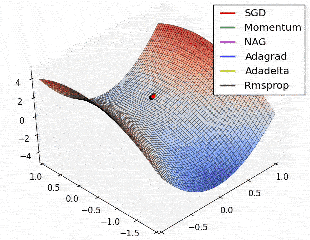

**1. Gradient Descent**

An algorithm that iteratively moves in the direction of decreasing the gradient of a function at each step. The goal is to **find the minimum value of the objective function(finding a local minimum of a cost function).** In other word,Gradient descent is simply used to find the values of a function's parameters (coefficients) that minimize a cost function as far as possible.


**Remark:** Gradient Descent guarantees only finding a “local minimum”, not the “global minimum”. So if we start at a different position (initialize different values of parameters), we might end up getting a different minimum cost function and a different set of weights and parameters.

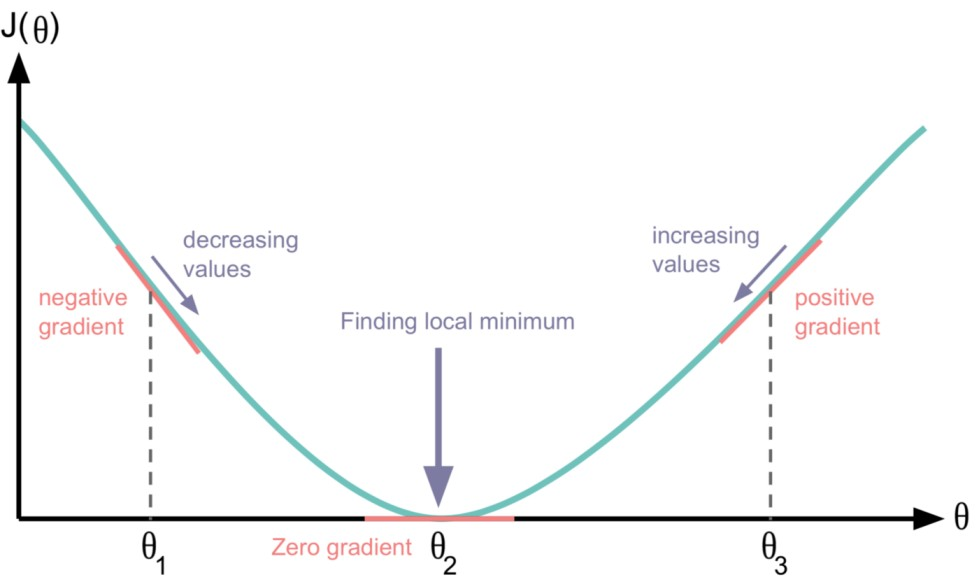

**Importance of Learning rate:**

How big the steps are gradient descent takes into the direction of the local minimum are determined by the learning rate, which figures out how fast or slows we will move towards the optimal weights.

**For gradient descent to reach the local minimum we must set the learning rate to an appropriate value, which is neither too low nor too high. This is important because if the steps it takes are too big, it may not reach the local minimum because it bounces back and forth between the convex function of gradient descent. If we set the learning rate to a very small value, gradient descent will eventually reach the local minimum but that may take a while. So, the learning rate should never be too high or too low for this reason. You can check if you’re learning rate is doing well by plotting it on a graph.**

**Advantages:**

>* **Easy computation.**
>* **Easy to implement.**
>* **Easy to understand.**


**Disadvantages:**

>* **May trap at local minima.**
>* **Weights are changed after calculating the gradient on the whole dataset. So, if the dataset is too large then this may take years to converge to the minima.**
>* **Requires large memory to calculate the gradient on the whole dataset.**

**2. Stochastic Gradient Descent (SGD)**

SGD algorithm is an extension of the Gradient Descent and it overcomes some of the disadvantages of the GD algorithm. Gradient Descent has a disadvantage that it requires a lot of memory to load the entire dataset of n-points at a time to compute the derivative of the loss function. **In the SGD algorithm derivative is computed taking one point at a time.**
This algorithm computes the gradient for a **single data sample instead of the entire dataset**, making it faster and less memory-intensive. It moves in the direction of reducing the gradient.

**Advantage:**

>* **Memory requirement is less compared to the GD algorithm as the derivative is computed taking only 1 point at once.**


**Disadvantages:**

>* **The time required to complete 1 epoch is large compared to the GD algorithm.**
>* **Takes a long time to converge.**
>* **May stuck at local minima.**

**3. Mini Batch Stochastic Gradient Descent (MB-SGD)**

MB-SGD algorithm is an extension of the SGD algorithm and it overcomes the problem of large time complexity in the case of the SGD algorithm. **MB-SGD algorithm takes a batch of points or subset of points from the dataset to compute derivate.**

It is observed that the derivative of the loss function for MB-SGD is almost the same as a derivate of the loss function for GD after some number of iterations. But the number of iterations to achieve minima is large for MB-SGD compared to GD and the cost of computation is also large.

**In summary,It divides the data into smaller batches and calculates the gradient for each batch. This approach speeds up optimization and allows for more computational efficiency.**


**Note:** The update of weight is dependent on the derivate of loss for a batch of points. The updates in the case of MB-SGD are much noisy because the derivative is not always towards minima.

**Advantages:**

>* **Less time complexity to converge compared to standard SGD algorithm.**


**Disadvantages:**

>* **The update of MB-SGD is much noisy compared to the update of the GD algorithm.**
>* **Take a longer time to converge than the GD algorithm.**
>* **May get stuck at local minima.**

**4. SGD with momentum**

A major disadvantage of the MB-SGD algorithm is that updates of weight are very noisy. **SGD with momentum overcomes this disadvantage by denoising the gradients. Updates of weight are dependent on noisy derivative and if we somehow denoise the derivatives then converging time will decrease.**

The idea is to denoise derivative using **exponential weighting average** that is to give more weightage to recent updates compared to the previous update.

It accelerates the convergence towards the relevant direction and reduces the fluctuation to the irrelevant direction.

In conclusion,This algorithm introduces a momentum concept to speed up optimization. The momentum helps the algorithm move in the correct direction towards a local minimum and prevents getting stuck in local minima.

**Advantages:**

>* **Has all advantages of the SGD algorithm.**
>* **Converges faster than the GD algorithm.**


**Disadvantages:**

>* **We need to compute one more variable for each update.**

**5. Nesterov Accelerated Gradient (NAG)**

The idea of the NAG algorithm is very similar to SGD with momentum with a slight variant. In the case of SGD with a momentum algorithm, the momentum and gradient are computed on the previous updated weight.

Momentum may be a good method but if the momentum is too high the algorithm may miss the local minima and may continue to rise up. So, to resolve this issue the NAG algorithm was developed. It is a look ahead method.

**In conclusion, this is an improved version of SGD with momentum that predicts the future gradient direction to adjust the movement, potentially accelerating optimization.**

**Both NAG and SGD with momentum algorithms work equally well and share the same advantages and disadvantages.**

**6. Adaptive Gradient Descent(AdaGrad)**

For all the previously discussed algorithms the learning rate remains constant. **So the key idea of AdaGrad is to have an adaptive learning rate for each of the weights.It performs smaller updates for parameters associated with frequently occurring features, and larger updates for parameters associated with infrequently occurring features.**

To summarize, AdaGrad uses an adaptive learning rate for each parameter. It adapts the learning rate based on the frequency and magnitude of previous gradients, leading to faster convergence for parameters with larger gradients.

**Advantage:**

>* **No need to update the learning rate manually as it changes adaptively with iterations.**

**Disadvantage:**

>* **As the number of iteration becomes very large learning rate decreases to a very small number which leads to slow convergence.**

**7. AdaDelta**

The problem with the previous algorithm AdaGrad was learning rate becomes very small with a large number of iterations which leads to slow convergence. **To avoid this, the AdaDelta algorithm has an idea to take an exponentially decaying average.**

Adadelta is a more robust extension of Adagrad that adapts learning rates based on a moving window of gradient updates, instead of accumulating all past gradients. This way, Adadelta continues learning even when many updates have been done. Compared to Adagrad, in the original version of Adadelta, you don't have to set an initial learning rate.

To summarize, Similar to AdaGrad, AdaDelta adapts the learning rate, but it improves the adaptation method. It uses a moving average of past squared gradients within a limited time window to determine the learning rate.

**8. RMSprop(Root Mean Square)**

RMSprop, like AdaGrad, uses **adaptive learning rates for each parameter**. However, it uses a different method to adapt the learning rate, considering the moving average of squared gradients.

RMSprop and Adadelta have both been developed independently around the same time stemming from the need to resolve Adagrad's radically diminishing learning rates.

**9. Adaptive Moment Estimation (Adam)**

Adam is an optimization algorithm that **combines the advantages of SGD with momentum and RMSprop**. It utilizes adaptive learning rates and computes the average of past squared gradients to improve optimization speed and accuracy.

**To summarize:**

>* **Adam is a replacement optimization algorithm for stochastic gradient descent for training deep learning models.**
>* **Adam combines the best properties of the AdaGrad and RMSProp algorithms to provide an optimization algorithm that can handle sparse gradients on noisy problems.**
>* **Adam is relatively easy to configure where the default configuration parameters do well on most problems.**

**Conclusion**

>* **Adam is the best optimizers. If one wants to train the neural network in less time and more efficiently than Adam is the optimizer.For sparse data use the optimizers with dynamic learning rate.**

>* **If, want to use gradient descent algorithm than min-batch gradient descent is the best option.**

>* **It is observed that the SGD algorithm (red) is stuck at a saddle point. So SGD algorithm can only be used for shallow networks.**

>* **AdaGrad and AdaDelta algorithm can be used for sparse data.**

>* **Adam is the fastest algorithm to converge to minima and it is considered the best algorithm amongst all the algorithms discussed above.**

## **Define a single-layer perceptron in PyTorch**

The steps are as follows:

>* First, we are creating a sequential model from the TensorFlow Keras library.
>* By using the add method, we can add layers to the model.
>* Dense is the function used to add a layer of neurons to the model architecture.
>* 3 is the number of neurons in a layer.
>* input shape is the shape of the data we are passing (Batchsize, Rows, Columns, -).
>*  We will be using Softmax as our activation function for our output layer. Based on the type of prediction problem (multiclass classification).

>* In fact, using both input_shape=(X_train.shape[1],) and input_shape=(4,) is essentially the same and valid. Both methods are used to specify the input to the first layer of a neural network model with the same input dimensions (in this case, (120, 4)).
In your particular case where the input dimensions are (120, 4), you can directly use input_shape=(4,) for the first layer of your model, as X_train.shape[1], which represents the constant value 4, is predetermined.
In cases where the input dimensions might be variable and subject to change, using input_shape=(X_train.shape[1],) might be more logical as it allows the model to automatically adapt to valid settings based on new input dimensions. However, in this specific scenario, both approaches for the input to the first layer of the model are correct.

In [2]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [3]:
# Define the neural network model

class SingleLayerPerceptron(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


model = SingleLayerPerceptron(X_train.shape[1], len(label_encoder.classes_)).to(device)
model


SingleLayerPerceptron(
  (linear): Linear(in_features=4, out_features=3, bias=True)
)

**Before training, let's define a simple early-stopping rule. This stops training when the validation loss is no longer improving and helps reduce overfitting.**


In [4]:
patience = 10
min_delta = 1e-4


### **Compile the Model**

**Here we will define our optimization function and metrics:**

>* we used **adam optimization function** because it is the fastest algorithm to `converge to minima` and it is considered the best algorithm amongst all the algorithms discussed above.

>* The parameter **loss='sparse_categorical_crossentropy'** is used to specify the loss function in **multi-class classification problems when the labels are provided as integers. This loss function is particularly suitable when dealing with integer-based labels or sparse labels.**
In the provided example, the class labels range from 0 to 2 (for instance, representing different flower classes in the Iris dataset).

In [5]:
# Define the loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


### **Model Summary**

In [6]:
print('Neural Network Model Summary: ')
print(model)


Neural Network Model Summary: 
SingleLayerPerceptron(
  (linear): Linear(in_features=4, out_features=3, bias=True)
)


 ### **Train The Model**

Because the dataset is small, I'm keeping the epoch size high and the batch size around 16... A smaller batch size speeds up the model and reduces computational stress.

I'm going to use the testing data as the validation data because we don't have much to work with. However, you should not use them for the same purpose because your model will learn from the mistakes it makes during validation, resulting in data leakage. So I'm not going to stress the outcome. The emphasis should be on how it is done!


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=200, patience=10, min_delta=1e-4):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(device)
                labels = labels.to(device)
                outputs = model(features)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += labels.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch + 1}')
                break

    model.load_state_dict(best_state)
    return history


history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs=200,
    patience=patience,
    min_delta=min_delta,
)


 ### **Training and Validation Accuracy Plot**

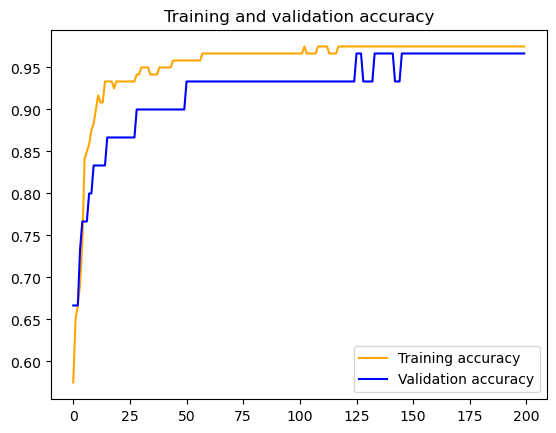

<Figure size 640x480 with 0 Axes>

In [8]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'orange', label='Training accuracy')
plt.plot(epochs, val_acc, 'blue', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()


 ### **Model Evaluation**

In [9]:
# Evaluate the model on the test data

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    predictions = logits.argmax(dim=1).cpu().numpy()

accuracy = accuracy_score(y_test, predictions)
print(f'Model accuracy on test data: {accuracy * 100:.2f}%')


Model accuracy on test data: 96.67%


In [10]:
with torch.no_grad():
    y_pred_logits = model(X_test_tensor.to(device))
    y_pred_probs = torch.softmax(y_pred_logits, dim=1).cpu().numpy()

y_pred_classes = np.argmax(y_pred_probs, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
print('Model Accuracy: %.2f%%' % (accuracy * 100))


Model Accuracy: 96.67%


**The single-layer perceptron already performs well on the Iris dataset, but we can still add a hidden layer to compare it with a deeper network.**


## **Define a Multiple Layer Perceptron model in PyTorch**

**Due to the low accuracy and the relatively small amount of data, I decided to use a hidden layer in the network structure.**

**Almost the rest of the parameters were set as before.**

In [11]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)


model2 = MultiLayerPerceptron(
    input_dim=X_train.shape[1],
    hidden_dim=10,
    output_dim=len(label_encoder.classes_),
).to(device)


In [12]:
criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)


In [13]:
print('Neural Network Model Summary: ')
print(model2)


Neural Network Model Summary: 
MultiLayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
  )
)


In [14]:
History = train_model(
    model2,
    train_loader,
    test_loader,
    criterion2,
    optimizer2,
    epochs=200,
    patience=patience,
    min_delta=min_delta,
)


Early stopping at epoch 29


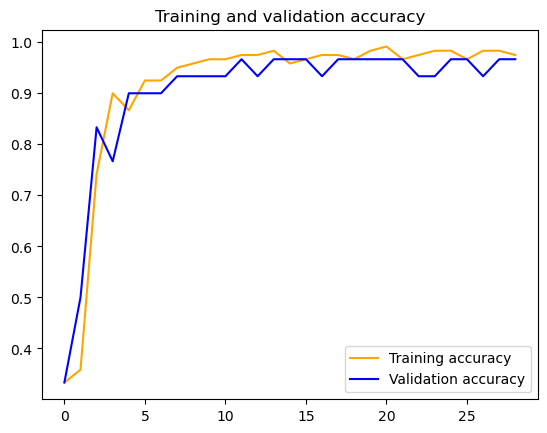

<Figure size 640x480 with 0 Axes>

In [15]:
acc = History['accuracy']
val_acc = History['val_accuracy']
loss = History['loss']
val_loss = History['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'orange', label='Training accuracy')
plt.plot(epochs, val_acc, 'blue', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()


In [16]:
# Evaluate the model on the test data

model2.eval()
with torch.no_grad():
    logits = model2(X_test_tensor.to(device))
    predictions = logits.argmax(dim=1).cpu().numpy()

accuracy = accuracy_score(y_test, predictions)
print(f'Model accuracy on test data: {accuracy * 100:.2f}%')


Model accuracy on test data: 96.67%


**The multi-layer perceptron provides a second PyTorch implementation for comparison, and both models can be evaluated on the same test split.**


**Congratulations!**
**You now understand what it takes to create a very simple neural network model.**